In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sys
import localSettings as ls
import math
print(ls.main_path)
import load_data_run123
import plotter_alex
import importlib
importlib.reload(plotter_alex)
import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import pickle
import xgboost as xgb
import nue_booster 
importlib.reload(nue_booster)
import awkward
from matplotlib import gridspec
from collections import defaultdict

/home/alex/NuMI/PELEE/


In [4]:
ending = "Jan19b_Data"
ending_nod = "Jan19b"


##  Energy

## Closure Tests

## Blockwise Unfolding

In [6]:

#with open('../blockwise/stv-analysis-new/blockwise_unsmeared_events_angle_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
with open('/media/alex/TOSHIBA EXT/ThesisAnalysisFiles/NuMI/blockwise/stv-analysis-new/blockwise_unsmeared_events_angle_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
events = content[0:]
    
for i in range(20):
    events[i]=events[i].rstrip().rstrip(',')
    events[i] = float(events[i])
    
print("Unsmeared events")
print(events)
print("")

#------------------------------------------------------------------------------
with open('/media/alex/TOSHIBA EXT/ThesisAnalysisFiles/NuMI/blockwise/stv-analysis-new/blockwise_unsmeared_AC_angle_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
AC = content[0:]
    
for i in range(400):
    AC[i]=AC[i].rstrip().rstrip(',')
    AC[i] = float(AC[i])
    

chunks = [AC[x:x+20] for x in range(0, len(AC), 20)]

print("AC")
print(chunks)
print("")
#---------------------------------------------------------------

with open('nue_full_500_catsel_nopions_angleDiff_usingSelection_prior_true_signal_blockwise_recoCut_comb_'+ending_nod+'.csv') as file:
    content = file.readlines()
prior_true = content[0:]
    
for i in range(20):
    prior_true[i]=prior_true[i].rstrip().rstrip(',')
    prior_true[i] = float(prior_true[i])
    
print("Prior Truth: ")
print(prior_true)
print("")

#----------------------------------------------------------------
with open('/media/alex/TOSHIBA EXT/ThesisAnalysisFiles/NuMI/blockwise/stv-analysis-new/blockwise_unsmeared_errors_angle_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
errs = content[0:]
    
for i in range(20):
    errs[i]=errs[i].rstrip().rstrip(',')
    errs[i] = float(errs[i])
    
print("Errors: ")
print(errs)
print("")
print("################################################################")
print("")

#----------------------------------------------------------------
with open('/media/alex/TOSHIBA EXT/ThesisAnalysisFiles/NuMI/blockwise/stv-analysis-new/blockwise_unsmeared_cov_matrix_angle_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
cov = content[0:]
    
for i in range(400):
    cov[i]=cov[i].rstrip().rstrip(',')
    cov[i] = float(cov[i])
    

chunks_cov = [cov[x:x+20] for x in range(0, len(cov), 20)]

print("cov")
print(chunks_cov)
print("")


Unsmeared events
[-37.3532, 23.3778, 67.8801, 3.42111, 65.7397, 87.4907, 29.6776, 144.487, 158.35, 371.693, 600.475, 557.679, 367.045, 1253.81, 997.752, 1208.27, 1558.41, 2112.79, 3269.01, 5613.91]

AC
[[0.443823, -0.109619, -0.0894533, 0.0967427, -0.0145963, -0.0355786, 0.0416185, -0.15106, -0.0519947, 0.0568892, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [-0.109619, 0.312961, 0.0784327, -0.0599426, -0.0153043, 0.00386113, 0.00104027, 0.0781257, 0.0270554, -0.0087459, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [-0.0894533, 0.0784327, 0.132688, 0.0230242, 0.00629186, 0.0440624, -0.0149232, 0.0970406, 0.106895, 0.00622972, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0967427, -0.0599426, 0.0230242, 0.272709, -0.0678783, -0.114309, 0.0159963, -0.0230347, 0.108502, 0.00109379, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [-0.0145963, -0.0153043, 0.00629186, -0.0678783, 0.261598, 0.0603101, -0.0882156, 0.205447, -0.00776838, 0.00659233, 0.0, 0.0, 0.0, 0.0, 0.

In [7]:
with open('../blockwise/stv-analysis-new/blocks.txt') as file:
    content = file.readlines()
blocks = content[0:]

print(blocks)

['20\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  0\n', '7  0\n', '8  0\n', '9  0\n', '10 1\n', '11 1\n', '12 1\n', '13 1\n', '14 1\n', '15 1\n', '16 1\n', '17 1\n', '18 1\n', '19 1\n', '20\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  0\n', '7  0\n', '8  0\n', '9  0\n', '10 1\n', '11 1\n', '12 1\n', '13 1\n', '14 1\n', '15 1\n', '16 1\n', '17 1\n', '18 1\n', '19 1\n']


In [8]:

made_data_sig = np.dot(prior_true, chunks)
print("Prior_Truth x AC: ")
print(made_data_sig)
print("")
print("")
print("Unfolding Done with MC Data Signal: ")
print(events)
print("")

diff = made_data_sig - events
print("")
print("Difference")
print(diff)

#for i in made_data_sig:
#    print(i)

print("")
diffasfrac = np.nan_to_num(diff/made_data_sig)
print(diffasfrac*100)

Prior_Truth x AC: 
[  10.44525614   18.69312047   49.46451488   26.05973156   36.71559558
   63.35500642   50.00280256  109.21743919  176.28282559  496.8956682
  419.87560921  396.05395607  484.31959683  762.34448188  824.30432583
 1073.56303208 1639.0526552  2182.02110973 4092.97384438 9811.67454573]


Unfolding Done with MC Data Signal: 
[-37.3532, 23.3778, 67.8801, 3.42111, 65.7397, 87.4907, 29.6776, 144.487, 158.35, 371.693, 600.475, 557.679, 367.045, 1253.81, 997.752, 1208.27, 1558.41, 2112.79, 3269.01, 5613.91]


Difference
[  47.79845614   -4.68467953  -18.41558512   22.63862156  -29.02410442
  -24.13569358   20.32520256  -35.26956081   17.93282559  125.2026682
 -180.59939079 -161.62504393  117.27459683 -491.46551812 -173.44767417
 -134.70696792   80.6426552    69.23110973  823.96384438 4197.76454573]

[457.60922951 -25.06098187 -37.2298913   86.87204436 -79.0511606
 -38.09595318  40.64812675 -32.29297544  10.1727582   25.19697317
 -43.01259393 -40.80884472  24.21429932 -64.4676

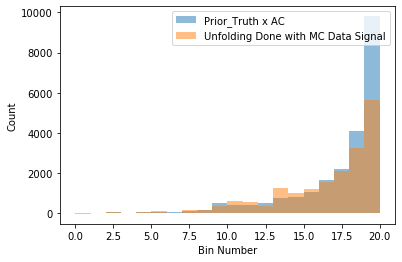

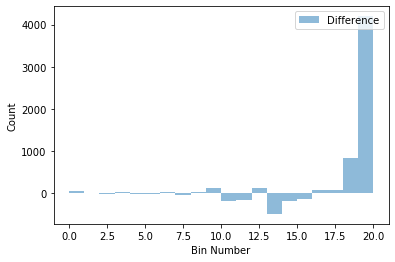

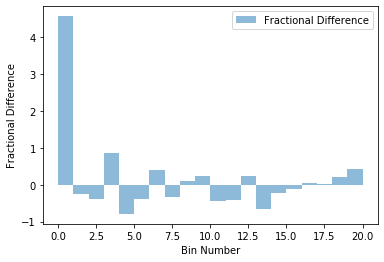

In [9]:
import random
import numpy
from matplotlib import pyplot

bins = np.arange(0, 21, 1)
count = np.arange(0.0, 20.0, 1)

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()

pyplot.hist(count, bins, weights=diff, alpha=0.5, label='Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()


pyplot.hist(count, bins, weights=diffasfrac, alpha=0.5, label='Fractional Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Fractional Difference")
pyplot.show()

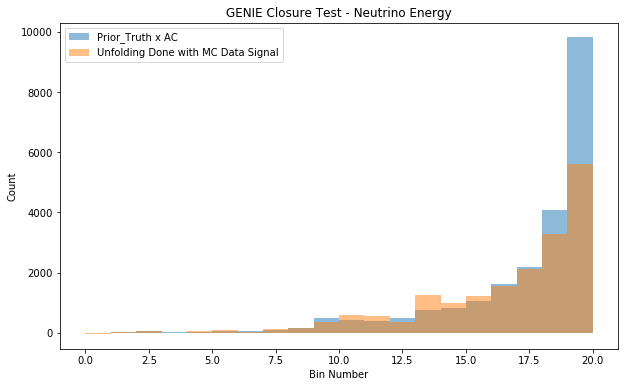

In [10]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper left')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.title("GENIE Closure Test - Neutrino Energy")
pyplot.show()

fig.savefig("Data_closure_test_angle_"+ending+".svg",bbox_inches='tight' )

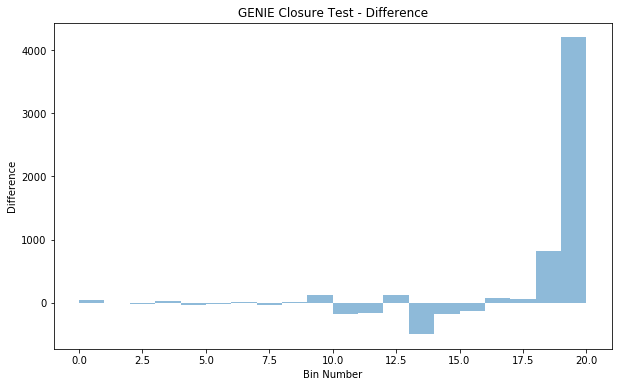

In [11]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=diff, alpha=0.5)
#pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Difference")
pyplot.title("GENIE Closure Test - Difference")
pyplot.show()

fig.savefig("Data_closure_test_diff_angle_"+ending+".svg",bbox_inches='tight' )

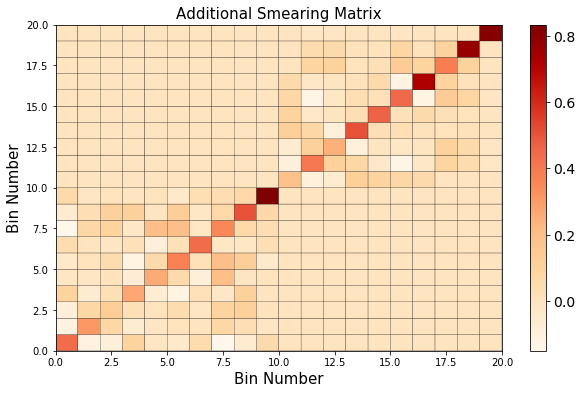

In [12]:
fig = plt.figure(figsize=(10, 6))  
    
plt.pcolor(bins, bins, chunks, cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title('Additional Smearing Matrix', fontsize=15)

plt.show()

fig.savefig("Data_closure_test_Ac_angle_"+ending+".svg",bbox_inches='tight' )

/tmp/ipykernel_249094/4171617754.py:7: RuntimeWarning: invalid value encountered in log
  plt.pcolor(bins, bins, np.log(chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)


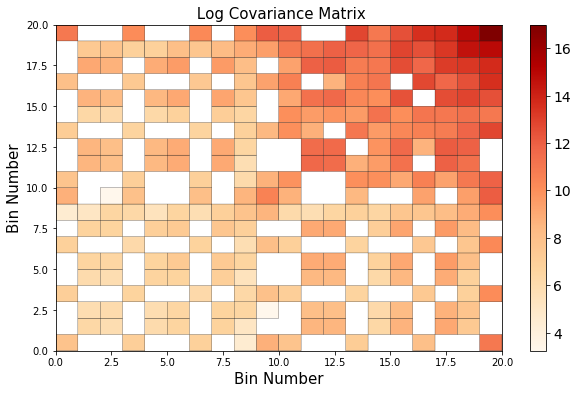

In [13]:
fig = plt.figure(figsize=(10, 6))  

#print(bins)
bins = np.arange(0, 21, 1)
count = np.arange(0.0, 20.0, 1)
    
plt.pcolor(bins, bins, np.log(chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

## Need to convert to xsec units

xsec = unfolded event counts / (integrated flux * number of argon targets)

In [14]:
###################
### #N argon target calculation
###################

density = 1.3836  #g/cm^3
volume = (246-10)*(106-(-106))*(1026-10)         #cm^3
NA = 6.022E23   #atoms/mol
Nnuc = 40       #nucleans / atom
mmol = 39.95    #g/mol

Narg = (density * volume * NA * Nnuc)/mmol   #nucleons

print("number of argon targets = ", Narg)

number of argon targets =  4.240685683288815e+31


In [15]:
#Need R1 AND R3

####NUE
POT_R1 = 2.0E20 
int_flux_per_POT_R1 = 1.1864530596659353e-11
POT_R3 = 5.014E20
int_flux_per_POT_R3 = 8.628376225834778e-12

int_flux = (int_flux_per_POT_R1*POT_R1) + (int_flux_per_POT_R3*POT_R3)    #cm^-2

print("Nue integrated flux: ", int_flux)

####NUMU

POT_numu_R1 = 2.0E20 
int_flux_per_POT_numu_R1 = 5.455771063338641e-10
POT_numu_R3 = 5.014E20 
int_flux_per_POT_numu_R3 = 3.6729003479115414e-10

int_flux_numu = (int_flux_per_POT_numu_R1*POT_numu_R1) + (int_flux_per_POT_numu_R3*POT_numu_R3)    #cm^-2

print("Numu integrated flux: ", int_flux_numu)

Nue integrated flux:  6699173958.965427
Numu integrated flux:  293274644711.0575


In [16]:
nue_events = np.array(events[0:10])
numu_events = np.array(events[10:20])

nue_errs = np.array(errs[0:10])
numu_errs = np.array(errs[10:20])

In [17]:
#number of events

xsec_nue_events = nue_events / (int_flux * Narg* 0.25)     
xsec_numu_events = numu_events / (int_flux_numu * Narg *0.25)     


#uncertainty

#xsec_nue_errs = nue_errs / (int_flux * Narg )     
#xsec_numu_errs = numu_errs / (int_flux_numu * Narg )     

In [18]:
#Need the four sections of the cov matrix

blockwise_errs = chunks_cov
#print(blockwise_errs)
#print("")

#NUE ONLY
bot_left = blockwise_errs[:10]
for i in range(len(bot_left)):
    bot_left[i] = bot_left[i][:10]
    
nue_errs_bot = np.array(bot_left)/((int_flux*int_flux)*(Narg*Narg)*(0.25*0.25))
xsec_nue_errs = (np.sqrt(np.diag(nue_errs_bot)))
    
#MIX
bot_right = blockwise_errs[:10]
for i in range(len(bot_right)):
    bot_right[i] = bot_right[i][10:]
    
mix_errs_bot = np.array(bot_right)/((int_flux*int_flux_numu)*(Narg*Narg)*(0.25*0.25))
xsec_botmix_errs = np.nan_to_num(np.sqrt(np.diag(mix_errs_bot)))

    
#MIX
top_left = blockwise_errs[10:]
for i in range(len(top_left)):
    top_left[i] = top_left[i][:10]
    
mix_errs_top = np.array(top_left)/((int_flux*int_flux_numu)*(Narg*Narg)*(0.25*0.25))
xsec_topmix_errs = np.nan_to_num(np.sqrt(np.diag(mix_errs_top)))

#NUMU ONLY
top_right = blockwise_errs[10:]
for i in range(len(top_right)):
    top_right[i] = top_right[i][10:]
    
numu_errs_top = np.array(top_right)/((int_flux_numu*int_flux_numu)*(Narg*Narg)*(0.25*0.25))
xsec_numu_errs = (np.sqrt(np.diag(numu_errs_top)))


/tmp/ipykernel_249094/429040335.py:9: RuntimeWarning: invalid value encountered in log
  plt.pcolor(bins, bins, np.log(bot_left), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)


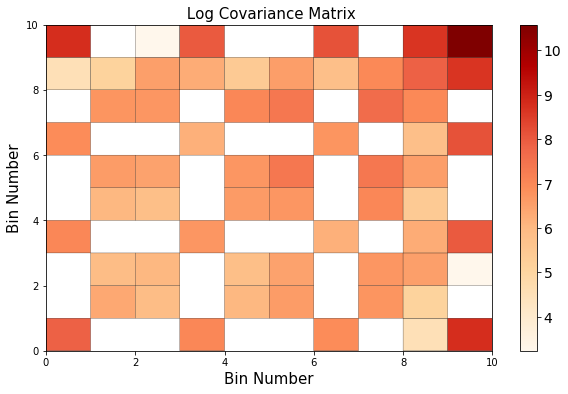

In [19]:
#BOT LEFT

fig = plt.figure(figsize=(10, 6))  

#print(bins)
bins = np.arange(0, 11, 1)
count = np.arange(0.0, 10.0, 1)
    
plt.pcolor(bins, bins, np.log(bot_left), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

/tmp/ipykernel_249094/196648468.py:9: RuntimeWarning: invalid value encountered in log
  plt.pcolor(bins, bins, np.log(bot_right), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)


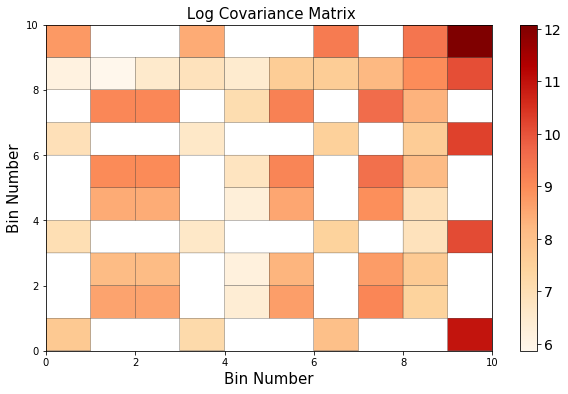

In [20]:
#BOT RIGHT

fig = plt.figure(figsize=(10, 6))  

#print(bins)
bins = np.arange(0, 11, 1)
count = np.arange(0.0, 10.0, 1)
    
plt.pcolor(bins, bins, np.log(bot_right), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

/tmp/ipykernel_249094/2783276082.py:9: RuntimeWarning: invalid value encountered in log
  plt.pcolor(bins, bins, np.log(top_left), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)


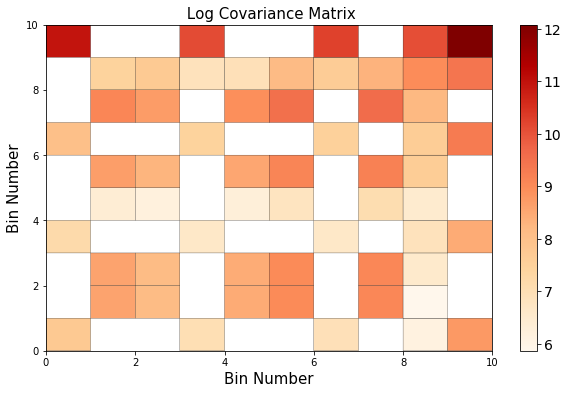

In [21]:
#TOP LEFT

fig = plt.figure(figsize=(10, 6))  

#print(bins)
bins = np.arange(0, 11, 1)
count = np.arange(0.0, 10.0, 1)
    
plt.pcolor(bins, bins, np.log(top_left), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

/tmp/ipykernel_249094/3954721658.py:9: RuntimeWarning: invalid value encountered in log
  plt.pcolor(bins, bins, np.log(top_right), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)


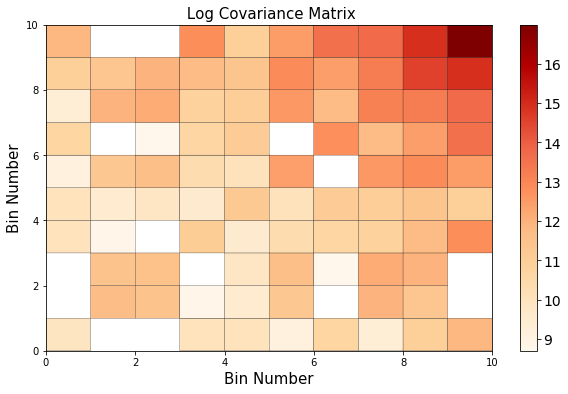

In [22]:
#TOP RIGHT

fig = plt.figure(figsize=(10, 6))  

#print(bins)
bins = np.arange(0, 11, 1)
count = np.arange(0.0, 10.0, 1)
    
plt.pcolor(bins, bins, np.log(top_right), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

/tmp/ipykernel_249094/4171617754.py:7: RuntimeWarning: invalid value encountered in log
  plt.pcolor(bins, bins, np.log(chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)


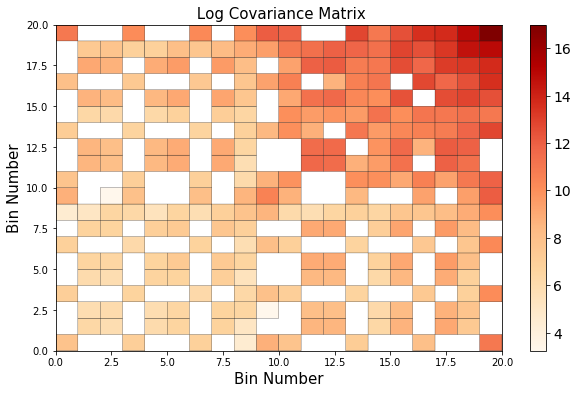

In [23]:
fig = plt.figure(figsize=(10, 6))  

#print(bins)
bins = np.arange(0, 21, 1)
count = np.arange(0.0, 20.0, 1)
    
plt.pcolor(bins, bins, np.log(chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

In [24]:
#Put it back together with it's new units

#cov_xsec = np.zeros_like(blockwise_errs)
#print(cov_xec)
print("----------------")

cov_xsec = np.block([[nue_errs_bot,mix_errs_bot],[mix_errs_top,numu_errs_top]])
print(cov_xsec)
print("")

print((np.sqrt(np.diag(cov_xsec))))
print("")
print(xsec_nue_errs)
print(xsec_numu_errs)

----------------
[[ 5.24619441e-79 -2.25318925e-79 -1.37453347e-79  2.22287738e-79
  -1.88355488e-79 -3.24378685e-79  1.99602403e-79 -3.32163821e-79
   1.84641738e-80  1.27824123e-78  1.07776816e-80 -5.86233822e-80
  -5.76429672e-80  6.03115979e-81 -4.97570796e-81 -6.09555472e-80
   1.39216211e-80 -8.89646223e-80 -1.29006310e-81  2.67383395e-79]
 [-2.25318925e-79  1.17516301e-79  7.33813005e-80 -9.26468854e-80
   8.49376777e-80  1.46309806e-79 -6.98868112e-80  1.68599045e-79
   3.31420397e-80 -3.86116578e-79 -4.03545150e-81  2.46398439e-80
   2.45998121e-80 -1.63760550e-81  2.69726428e-81  2.72339359e-80
  -3.63617126e-81  4.04327670e-80  7.73916498e-81 -8.80163594e-80]
 [-1.37453347e-79  7.33813005e-80  8.56115172e-80 -2.95176991e-80
   7.01191560e-80  1.30369408e-79 -3.42058299e-80  1.65228063e-79
   1.37583198e-79  5.02689425e-81 -2.14274338e-81  1.56824736e-80
   1.58496197e-80 -2.53523089e-82  2.22293362e-81  1.84434853e-80
  -7.53524771e-82  2.79072296e-80  1.05606318e-80 -3.8613

In [25]:
### Calculate ratio uncertainties

xsec_ratio_events = np.nan_to_num(xsec_nue_events/xsec_numu_events)
print("Ratio event counts: ", xsec_ratio_events)
print("")

#####################

ratio_sq = (xsec_nue_events/xsec_numu_events)*(xsec_nue_events/xsec_numu_events)
print("ratio_sq: ", ratio_sq)
print("")
nue_term = (xsec_nue_errs*xsec_nue_errs)/(xsec_nue_events*xsec_nue_events)
print("nue: ", nue_term)
print("")
numu_term = (xsec_numu_errs*xsec_numu_errs)/(xsec_numu_events*xsec_numu_events)
print("numu: ", numu_term)
print("")
mix_1 = (xsec_botmix_errs*xsec_botmix_errs)/(xsec_numu_events*xsec_nue_events)
print("mix: ", mix_1)
print("")
mix_2 = (xsec_topmix_errs*xsec_topmix_errs)/(xsec_numu_events*xsec_nue_events)
print("mix: ", mix_2)
print("")

ratio_var_errs = ratio_sq*(nue_term + numu_term - mix_1 - mix_2)
print(ratio_var_errs)
xsec_ratio_errs = np.nan_to_num(np.sqrt(abs(ratio_var_errs)))
print("Ratio errs: ", xsec_ratio_errs)

Ratio event counts:  [-2.72324142  1.8351544   8.09611043  0.11945066  2.88441917  3.16994087
  0.83368178  2.99382012  2.12058205  2.89849262]

ratio_sq:  [7.41604384e+00 3.36779168e+00 6.55470040e+01 1.42684613e-02
 8.31987393e+00 1.00485251e+01 6.95025318e-01 8.96295893e+00
 4.49686822e+00 8.40125944e+00]

nue:  [ 1.89663365  1.08463979  0.09372209 70.38828163  0.17624698  0.21605245
  0.96769274  0.10348481  0.10567894  0.28409688]

numu:  [0.05584543 0.39801178 0.78406626 0.04134311 0.07769593 0.17571006
 0.14798395 0.11757816 0.20340476 0.76319048]

mix:  [-0.10610859  0.41734766  0.14047693  0.17945099  0.00813294  0.08804522
  0.03893006  0.0488989   0.01526034  0.08445782]

mix:  [-0.10610859  0.41734766  0.14047693  0.17945099  0.00813294  0.08804522
  0.03893006  0.0488989   0.01526034  0.08445782]

[16.05348242  2.1821817  39.12071209  0.9998014   1.97744292  2.16718636
  0.7213088   1.10482077  1.25266119  7.37942871]
Ratio errs:  [4.00667973 1.47722094 6.25465523 0.999900

In [26]:
print(xsec_nue_events)
print("")
print(xsec_numu_events)
print("")
print(xsec_nue_errs)
print("")
print(xsec_numu_errs)

[-5.25933053e-40  3.29159422e-40  9.55751802e-40  4.81692285e-41
  9.25614970e-40  1.23186905e-39  4.17860605e-40  2.03437695e-39
  2.22956799e-39  5.23343741e-39]

[1.93127590e-40 1.79363339e-40 1.18050737e-40 4.03256261e-40
 3.20901685e-40 3.88609473e-40 5.01223144e-40 6.79525443e-40
 1.05139435e-39 1.80557210e-39]

[7.24306179e-40 3.42806507e-40 2.92594459e-40 4.04128866e-40
 3.88589632e-40 5.72590510e-40 4.11055222e-40 6.54439850e-40
 7.24794578e-40 2.78946084e-39]

[4.56392131e-41 1.13157058e-40 1.04530995e-40 8.19941149e-41
 8.94481014e-41 1.62896480e-40 1.92813939e-40 2.33007049e-40
 4.74183236e-40 1.57736176e-39]


No handles with labels found to put in legend.


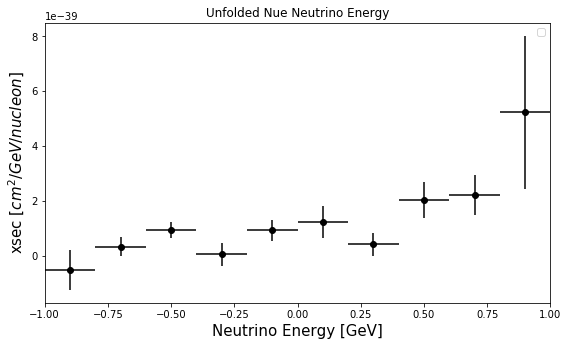

In [27]:
import random
import numpy
from matplotlib import pyplot



nue_fig = plt.figure(figsize=(8, 7))
nue_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_ax1 = plt.subplot(nue_gs[0])

nue_ax1.set_xlim([-1, 1])
current_bincenters =  np.arange(-0.9, 1.1, 0.2)
current_bin_size = 0.2

nue_ax1.errorbar(
            current_bincenters,
            xsec_nue_events,
            xerr=current_bin_size/2,
            yerr=xsec_nue_errs,
            fmt='ko')

plt.title("Unfolded Nue Neutrino Energy")
plt.xlabel("Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('xsec $[cm^2 / GeV / nucleon]$', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 2.5E-39)


nue_fig.savefig("unfolded_MC_nue_angle_"+ending+".svg",bbox_inches='tight' )

No handles with labels found to put in legend.


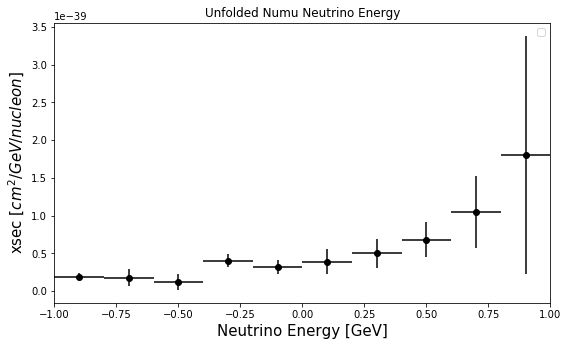

In [28]:
import random
import numpy
from matplotlib import pyplot

numu_fig = plt.figure(figsize=(8, 7))
numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
numu_ax1 = plt.subplot(numu_gs[0])

numu_ax1.set_xlim([-1, 1])
current_bincenters =  np.arange(-0.9, 1.1, 0.2)
current_bin_size = 0.2

numu_ax1.errorbar(
            current_bincenters,
            xsec_numu_events,
            xerr=current_bin_size/2,
            yerr=xsec_numu_errs,
            fmt='ko')

plt.title("Unfolded Numu Neutrino Energy")
plt.xlabel("Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('xsec $[cm^2 / GeV / nucleon]$', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 1.0E-39)


numu_fig.savefig("unfolded_MC_numu_angle_"+ending+".svg",bbox_inches='tight' )

In [35]:
print(sum(xsec_ratio_events)/len(xsec_ratio_events))

2.22284106760988


No handles with labels found to put in legend.


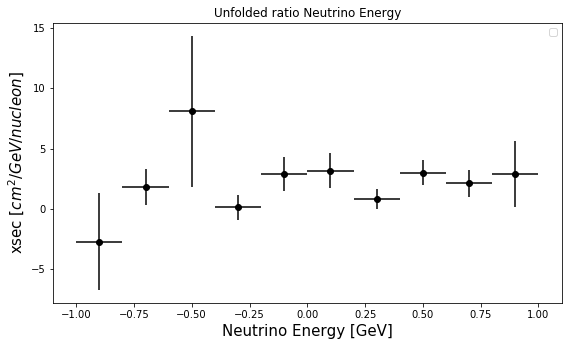

In [29]:
ratio_fig = plt.figure(figsize=(8, 7))
ratio_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
ratio_ax1 = plt.subplot(ratio_gs[0])

numu_ax1.set_xlim([-1, 1])
current_bincenters =  np.arange(-0.9, 1.1, 0.2)
current_bin_size = 0.2

ratio_ax1.errorbar(
            current_bincenters,
            xsec_ratio_events,
            xerr=current_bin_size/2,
            yerr=xsec_ratio_errs,
            fmt='ko')

plt.title("Unfolded ratio Neutrino Energy")
plt.xlabel("Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('xsec $[cm^2 / GeV / nucleon]$', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 2.5E-39)


ratio_fig.savefig("unfolded_MC_ratio_angle_"+ending+".svg",bbox_inches='tight' )

In [30]:
nue_frac_err = abs(xsec_nue_errs/xsec_nue_events)
numu_frac_err = abs(xsec_numu_errs/xsec_numu_events)
ratio_frac_err = abs(xsec_ratio_errs/xsec_ratio_events)

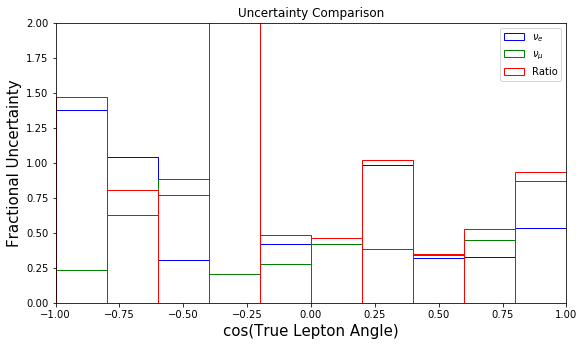

In [32]:
errors_fig = plt.figure(figsize=(8, 7))
errors_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
errors_ax1 = plt.subplot(ratio_gs[0])
errors_ax1.set_xlim([-1, 1]) 


bins = np.arange(-1, 1.2, 0.2)
count = [-0.9, -0.7, -0.5, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7, 0.9]


sel_nue = errors_ax1.hist(count, bins, edgecolor='blue', facecolor='None', weights=nue_frac_err, label='$\\nu_{e}$')
sel_numu = errors_ax1.hist(count, bins, edgecolor='green', facecolor='None', weights=numu_frac_err, label='$\\nu_{\\mu}$')
sel_ratio = errors_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=ratio_frac_err, label='Ratio')
errors_ax1.set_ylabel('Fractional Uncertainty', fontsize=15)
errors_ax1.set_xlabel('cos(True Lepton Angle)', fontsize=15)
errors_ax1.set_title("Uncertainty Comparison")
leg = errors_ax1.legend()

plt.tight_layout()
plt.ylim(0, 2)

errors_fig.savefig("unfolded_MC_errors_angle_"+ending+".svg",bbox_inches='tight' )

## Now compare the unfolded result to the GENIE prior truth x Ac

In [29]:
smeared_truth = np.dot(prior_true, chunks)
#smeared_nuWro = np.dot(prior_true_nuWro, nuWro_Ac)
print("Prior_Truth x AC: ")
print(smeared_truth)

Prior_Truth x AC: 
[  10.44525614   18.69312047   49.46451488   26.05973156   36.71559558
   63.35500642   50.00280256  109.21743919  176.28282559  496.8956682
  419.87560921  396.05395607  484.31959683  762.34448188  824.30432583
 1073.56303208 1639.0526552  2182.02110973 4092.97384438 9811.67454573]


In [30]:
nue_smeared_truth = np.array(smeared_truth[0:10])
numu_smeared_truth = np.array(smeared_truth[10:20])

In [31]:
xsec_nue_smeared_truth = nue_smeared_truth / (int_flux * Narg *0.25)     
xsec_numu_smeared_truth = numu_smeared_truth / (int_flux_numu * Narg *0.25) 


xsec_ratio_smeared_truth = np.nan_to_num(xsec_nue_smeared_truth/xsec_numu_smeared_truth)
print("Ratio event counts: ", xsec_ratio_smeared_truth)

Ratio event counts:  [1.08905975 2.06623974 4.47110608 1.49648352 1.94991761 2.58348922
 1.33553324 2.19122162 1.88549027 2.21704924]


In [32]:
bins = np.arange(-1, 1.2, 0.2)
count = np.arange(-0.9, 1.1, 0.2)

print(bins)
print(count)

[-1.00000000e+00 -8.00000000e-01 -6.00000000e-01 -4.00000000e-01
 -2.00000000e-01 -2.22044605e-16  2.00000000e-01  4.00000000e-01
  6.00000000e-01  8.00000000e-01  1.00000000e+00]
[-0.9 -0.7 -0.5 -0.3 -0.1  0.1  0.3  0.5  0.7  0.9]


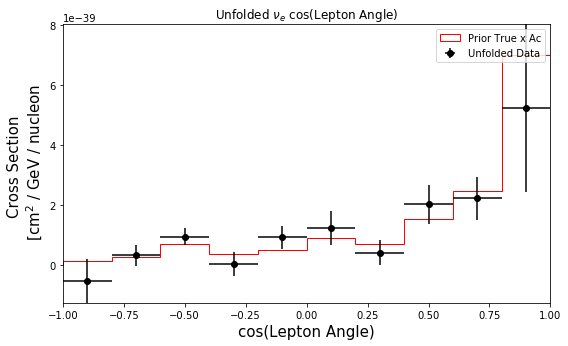

In [33]:
nue_fig = plt.figure(figsize=(8, 7))
nue_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_ax1 = plt.subplot(nue_gs[0])

nue_ax1.set_xlim([-1, 1])
current_bincenters =  np.arange(-0.9, 1.1, 0.2)
current_bin_size = 0.2

nue_ax1.errorbar(
            current_bincenters,
            xsec_nue_events,
            xerr=current_bin_size/2,
            yerr=xsec_nue_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_nue = nue_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_nue_smeared_truth, label='Prior True x Ac', histtype="step")
#nue_ax1.step(count, bins, label='Prior True x Ac')



plt.title("Unfolded $\\nu_{e}$ cos(Lepton Angle)")
plt.xlabel("cos(Lepton Angle)", fontsize=15)
plt.ylabel('Cross Section \n [cm$^2$ / GeV / nucleon', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 2.5E-39)

nue_fig.savefig("unfolded_MC_nue_angle_comp_"+ending+".svg",bbox_inches='tight' )

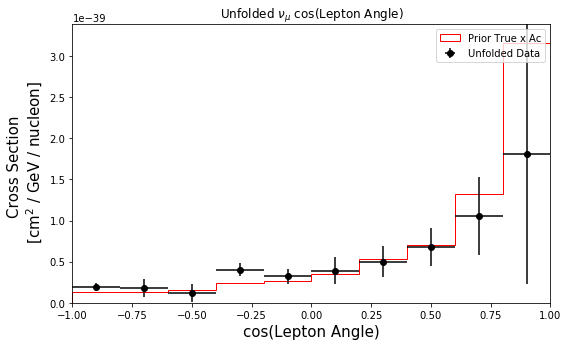

In [36]:
numu_fig = plt.figure(figsize=(8, 7))
numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
numu_ax1 = plt.subplot(numu_gs[0])

numu_ax1.set_xlim([-1, 1])
current_bincenters =  np.arange(-0.9, 1.1, 0.2)
current_bin_size = 0.2

numu_ax1.errorbar(
            current_bincenters,
            xsec_numu_events,
            xerr=current_bin_size/2,
            yerr=xsec_numu_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_numu = numu_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_numu_smeared_truth, label='Prior True x Ac', histtype="step")
#nue_ax1.step(count, bins, label='Prior True x Ac')



plt.title("Unfolded $\\nu_{\\mu}$ cos(Lepton Angle)")
plt.xlabel("cos(Lepton Angle)", fontsize=15)
plt.ylabel('Cross Section \n [cm$^2$ / GeV / nucleon]', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 2.5E-39)

numu_fig.savefig("unfolded_MC_numu_angle_comp_"+ending+".svg",bbox_inches='tight' )

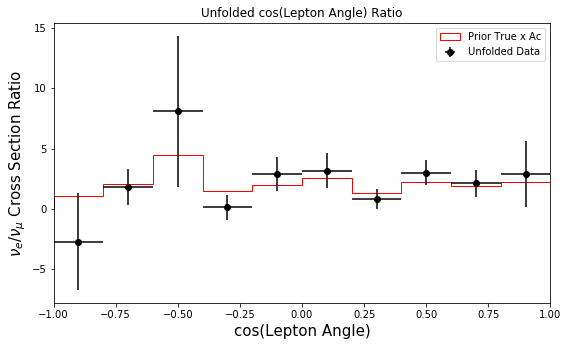

In [37]:
ratio_fig = plt.figure(figsize=(8, 7))
ratio_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
ratio_ax1 = plt.subplot(ratio_gs[0])

ratio_ax1.set_xlim([-1, 1])
current_bincenters =  np.arange(-0.9, 1.1, 0.2)
current_bin_size = 0.2

ratio_ax1.errorbar(
            current_bincenters,
            xsec_ratio_events,
            xerr=current_bin_size/2,
            yerr=xsec_ratio_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_ratio = ratio_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_ratio_smeared_truth, label='Prior True x Ac', histtype="step")


plt.title("Unfolded cos(Lepton Angle) Ratio")
plt.xlabel("cos(Lepton Angle)", fontsize=15)
plt.ylabel('$\\nu_{e}$/$\\nu_{\\mu}$ Cross Section Ratio', fontsize=15)
plt.legend()
plt.tight_layout()

#plt.ylim(0, 5)

ratio_fig.savefig("unfolded_MC_ratio_angle_comp_"+ending+".svg",bbox_inches='tight' )

## Some Chi2 Tests

In [38]:
#NUE

import scipy.stats as sp

f_obs_nue = xsec_nue_events
f_exp_nue = f_exp_nue[0]

print(f_obs_nue)
print(f_exp_nue)

[-5.25933053e-40  3.29159422e-40  9.55751802e-40  4.81692285e-41
  9.25614970e-40  1.23186905e-39  4.17860605e-40  2.03437695e-39
  2.22956799e-39  5.23343741e-39]
[1.47069205e-40 2.63199134e-40 6.96460365e-40 3.66921018e-40
 5.16955582e-40 8.92038484e-40 7.04039455e-40 1.53778153e-39
 2.48206217e-39 6.99629096e-39]


In [39]:
inverse_unfcov_nue = np.linalg.inv(nue_errs_bot)

In [40]:
chi2_genie_nue = 0

print(len(bins)-1)
print(len(f_obs_nue))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_nue)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_nue = chi2_genie_nue  + ( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov_nue[i][j]*(f_obs_nue[j]-f_exp_nue[j]) )

10
10


In [41]:
chi2_genie_nue

10.22338847532319

In [42]:
#NUMU

f_obs_numu = xsec_numu_events
f_exp_numu = f_exp_numu[0]

print(f_obs_numu)
print(f_exp_numu)

[1.93127590e-40 1.79363339e-40 1.18050737e-40 4.03256261e-40
 3.20901685e-40 3.88609473e-40 5.01223144e-40 6.79525443e-40
 1.05139435e-39 1.80557210e-39]
[1.35042366e-40 1.27380734e-40 1.55769144e-40 2.45188813e-40
 2.65116629e-40 3.45284385e-40 5.27159813e-40 7.01791878e-40
 1.31640147e-39 3.15567685e-39]


In [43]:
inverse_unfcov_numu = np.linalg.inv(numu_errs_top)

In [44]:
chi2_genie_numu = 0

print(len(bins)-1)
print(len(f_obs_numu))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_numu)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_numu = chi2_genie_numu  + ( (f_obs_numu[i]-f_exp_numu[i])*inverse_unfcov_numu[i][j]*(f_obs_numu[j]-f_exp_numu[j]) )

10
10


In [45]:
chi2_genie_numu

8.055527048036371

In [46]:
#RATIO

f_obs_ratio = xsec_ratio_events
f_exp_ratio = f_exp_ratio[0]

print(f_obs_ratio)
print(f_exp_ratio)

[-2.72324142  1.8351544   8.09611043  0.11945066  2.88441917  3.16994087
  0.83368178  2.99382012  2.12058205  2.89849262]
[1.08905975 2.06623974 4.47110608 1.49648352 1.94991761 2.58348922
 1.33553324 2.19122162 1.88549027 2.21704924]


In [47]:
nue_term = (nue_errs_bot)/(xsec_nue_events*xsec_nue_events)
#print("nue: ", nue_term)
#print("")
numu_term = (numu_errs_top)/(xsec_numu_events*xsec_numu_events)
#print("numu: ", numu_term)
#print("")
mix_1 = (mix_errs_bot)/(xsec_numu_events*xsec_nue_events)
#print("mix: ", mix_1)
#print("")
mix_2 = (mix_errs_top)/(xsec_numu_events*xsec_nue_events)
#print("mix: ", mix_2)
#print("")

ratio_var_errs = ratio_sq*(nue_term + numu_term - mix_1 - mix_2)
print(ratio_var_errs)
print(np.sqrt(np.diag(ratio_var_errs)))

[[ 1.60534824e+01 -3.61865605e+00  1.89517955e+01  1.35904500e+00
  -1.40196868e+00 -6.79494959e-01  7.45306727e-01 -8.25488880e-02
   3.97450395e-02  1.68186406e-01]
 [-1.09752091e+01  2.18218170e+00  3.07350763e+01 -5.51485706e-01
   2.59059943e-01  1.84508337e-01 -1.95364745e-01  1.65933568e-01
   4.79605516e-02 -8.57980591e-02]
 [-8.30050949e+00  1.07084629e+00  3.91207121e+01 -1.64629835e-01
   1.84098111e-01  4.87351449e-01 -6.40264269e-02  2.97606693e-01
   1.65657951e-01  5.32471017e-02]
 [ 7.23212787e+00 -1.39570817e+00  8.04672435e+00  9.99801397e-01
  -7.90088506e-01 -1.91524451e-01  3.65060354e-01  5.18912413e-02
   1.36875484e-01  1.65591942e-01]
 [-5.20485079e+00  1.40177375e+00  8.95160523e-01 -6.19147417e-01
   1.97744292e+00  6.73077918e-01 -3.10901087e-01  3.54664238e-01
   6.40051325e-02  4.34798750e-02]
 [-1.33922031e+01  1.76725185e+00  3.31497372e+01 -8.57259227e-01
   1.02204417e+00  2.16718636e+00 -3.58849805e-01  6.10114428e-01
   2.46195861e-01  1.30588960e-01

In [48]:
inverse_unfcov_ratio = np.linalg.inv(ratio_var_errs)

In [49]:
chi2_genie_ratio = 0

print(len(bins)-1)
print(len(f_obs_ratio))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_ratio)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_ratio = chi2_genie_ratio  + ( (f_obs_ratio[i]-f_exp_ratio[i])*inverse_unfcov_ratio[i][j]*(f_obs_ratio[j]-f_exp_ratio[j]) )

10
10


In [50]:
chi2_genie_ratio

20.30321813339353